In [20]:
import pandas as pd
import geopandas as gpd

buildings_gdf = gpd.read_file('./data/gatchina/buildings/buildings_all.shp')

In [22]:
buildings_gdf.groupby('floors').agg('size')

floors
-                                        5
1                                     4404
1-2                                      4
1-5                                      1
10                                      26
11                                       7
12                                      11
13                                       5
14                                       2
2                                     4106
2 (в том числе - мансарда)               1
2, в том числе мансарда                  1
2, мансарда                              1
2, мансардный этаж, цокольный этаж       1
2-9                                      1
3                                      549
4                                      151
5                                      517
5.5                                      1
6                                       95
7                                       19
7-5                                      1
7-9                                      1
8   

In [2]:
buildings_gdf.geom_type.unique()

array(['Polygon', 'MultiPolygon'], dtype=object)

<Axes: >

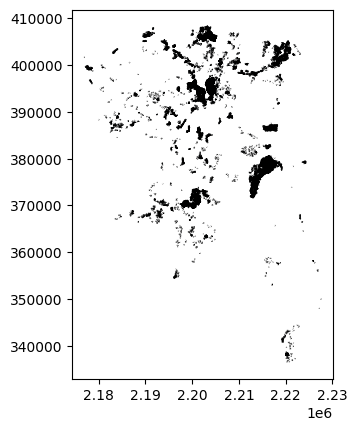

In [3]:
buildings_gdf.plot(linewidth=1, edgecolor='black')

## Очистка колонок

Убираем столбцы, в которых нет никакой информации

In [4]:
len(buildings_gdf.columns)

74

In [5]:
mask = ~buildings_gdf.isna().all()
columns = list(mask[mask].index)
buildings_gdf = buildings_gdf[columns].copy()

In [6]:
len(buildings_gdf.columns)

50

In [7]:
buildings_gdf.columns

Index(['LayerID', 'ObjectID', 'AREA_', 'AreaInaccu', 'cost', 'FID_',
       'cadastralD', 'category', 'categoryNa', 'descr', 'externalKe',
       'interactio', 'label', 'subcategor', 'build_reco', 'build_re_1',
       'build_re_2', 'building_n', 'cad_num', 'cost_appli', 'cost_appro',
       'cost_deter', 'cost_index', 'cost_regis', 'cost_value', 'cultural_h',
       'determinat', 'floors', 'materials', 'ownership_', 'permitted_',
       'previously', 'purpose', 'quarter_ca', 'readable_a', 'right_type',
       'status', 'undergroun', 'year_built', 'year_commi', 'systemInfo',
       'systemIn_1', 'systemIn_2', 'systemIn_3', 'Field', 'name', 'building_t',
       'Shape_Leng', 'Shape_Area', 'geometry'],
      dtype='object')

## Маппинг колонок

- `population : float`                 <- -
- `footprint_area : float`      <- `Shape_Area`
- `number_of_floors : float`    <- `floors`
- `build_floor_area : float`    <- -
- `is_living : bool`            <- `purpose`
- `living_area : float`         <- -
- `non_living_area : float`     <- -

### `footprint_area` <- `Shape_Area`

In [8]:
buildings_gdf['Shape_Area'].isna().any()

np.False_

In [9]:
buildings_gdf['footprint_area'] = buildings_gdf['Shape_Area']

### `number_of_floors` <- `floors`

In [10]:
buildings_gdf['floors'].isna().any()

np.True_

In [11]:
buildings_gdf['floors'].unique()

array(['2', '1', '3', '4', '-', '5', '7', '6', '2, мансарда', '10', '9',
       '14', '12', None, '8', '11', '2, мансардный этаж, цокольный этаж',
       '1-2', '2-9', '8-9', '2, в том числе мансарда', '7-5',
       '2 (в том числе - мансарда)', '13', '9-10', '7-9', '1-5', '5.5'],
      dtype=object)

In [12]:
def parse_floors(floors) -> float:
    try:
        return float(floors)
    except:
        if isinstance(floors, str):
            if floors == '-':
                return 1.0
            if floors[1] == '-':
                a,b = floors.split('-')
                return (float(a)+float(b))/2
            if floors[0] == '2':
                return float(floors[0]) 
        return 1.0

floors_rules = {f:parse_floors(f) for f in buildings_gdf['floors'].unique()}
floors_rules

{'2': 2.0,
 '1': 1.0,
 '3': 3.0,
 '4': 4.0,
 '-': 1.0,
 '5': 5.0,
 '7': 7.0,
 '6': 6.0,
 '2, мансарда': 2.0,
 '10': 10.0,
 '9': 9.0,
 '14': 14.0,
 '12': 12.0,
 None: 1.0,
 '8': 8.0,
 '11': 11.0,
 '2, мансардный этаж, цокольный этаж': 2.0,
 '1-2': 1.5,
 '2-9': 5.5,
 '8-9': 8.5,
 '2, в том числе мансарда': 2.0,
 '7-5': 6.0,
 '2 (в том числе - мансарда)': 2.0,
 '13': 13.0,
 '9-10': 9.5,
 '7-9': 8.0,
 '1-5': 3.0,
 '5.5': 5.5}

In [13]:
buildings_gdf['number_of_floors'] = buildings_gdf['floors'].map(floors_rules)

### `is_living` <- `purpose`

In [14]:
buildings_gdf.purpose.unique()

array(['Жилой дом', 'Нежилое', 'Садовый дом', 'Гараж',
       'Многоквартирный дом', None, 'Жилое'], dtype=object)

In [15]:
living_purposes = ['Жилой дом', 'Жилое', 'Многоквартирный дом']

buildings_gdf['is_living'] = buildings_gdf.purpose.isin(living_purposes)

### Восстановление остальных параметров

In [16]:
from blocksnet.preprocessing.imputing import impute_buildings

buildings_gdf = impute_buildings(buildings_gdf, default_number_of_floors=1, living_area_coefficient=0.8, default_living_demand=20)
buildings_gdf['population'] = 0.0
buildings_gdf.head()

2025-10-27 09:00:31.205 | WARNING  | blocksnet.preprocessing.imputing.buildings.schemas:_before_validate:21 - Column build_floor_area not found and will be initialized as None
2025-10-27 09:00:31.206 | WARNING  | blocksnet.preprocessing.imputing.buildings.schemas:_before_validate:21 - Column living_area not found and will be initialized as None
2025-10-27 09:00:31.206 | WARNING  | blocksnet.preprocessing.imputing.buildings.schemas:_before_validate:21 - Column non_living_area not found and will be initialized as None
2025-10-27 09:00:31.207 | WARNING  | blocksnet.preprocessing.imputing.buildings.schemas:_before_validate:21 - Column population not found and will be initialized as None


,geometry,is_living,number_of_floors,footprint_area,build_floor_area,living_area,non_living_area,population
0,"POLYGON Z ((2178278.56 399580.73 0, 2178282.07...",True,2.0,103.1410,206.2820,165.02560,41.25640,0.0
1,"POLYGON Z ((2183899.14 403478.94 0, 2183907.57...",True,1.0,169.2514,169.2514,135.40112,33.85028,0.0
2,"POLYGON Z ((2177666.17 399589.08 0, 2177661.04...",True,2.0,120.5829,241.1658,192.93264,48.23316,0.0
3,"POLYGON Z ((2180551.13 400021.99 0, 2180560.27...",True,1.0,134.3485,134.3485,107.47880,26.86970,0.0
4,"POLYGON Z ((2178419.66 399149.98 0, 2178422.38...",True,2.0,95.8145,191.6290,153.30320,38.32580,0.0


### Восстановление `population` из `TOTAL_POPULATION`

In [17]:
from blocksnet.preprocessing.imputing import impute_population

TOTAL_POPULATION = 91_514

population = impute_population(buildings_gdf, TOTAL_POPULATION)['population']
buildings_gdf['population'] = population

2025-10-27 09:00:31.340 | INFO     | blocksnet.preprocessing.imputing.population.core:impute_population:47 - Distributing 91514 population between 2874 rows


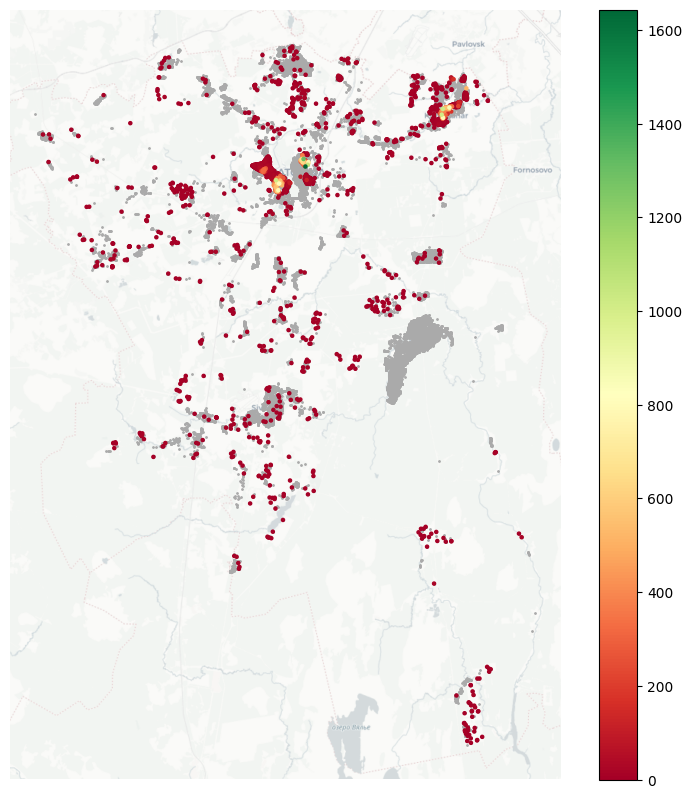

In [18]:
import contextily

gdf = buildings_gdf.copy()
gdf.geometry = gdf.representative_point()
gdf = gdf.sort_values('population').to_crs(3857)
ax = gdf.plot(color='#aaa',markersize=1,  figsize=(10,10))
gdf[gdf['population']>0].to_crs(3857).plot('population', ax=ax, vmin=0, cmap='RdYlGn', markersize=5, legend=True)
ax.set_axis_off()
contextily.add_basemap(ax, attribution=False, source=contextily.providers.CartoDB.Positron)

In [19]:
buildings_gdf.to_file('buildings.geojson')